In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import scanpy as sc
from itertools import product
from scipy.stats import spearmanr
from sklearn.neighbors import NearestNeighbors

sc.settings.verbosity = 2

# Load data

In [2]:
%%time
# h5ad built in Hematokytos/figure3/timeseries_embedding.ipynb
fpath = "/nfs/turbo/umms-indikar/shared/projects/parse/anndatas/scfib_hsc_parse_integration_wFA.h5ad"

fdata = sc.read_h5ad(fpath)

# threshold scANVI prediction probabilities to assign a hard label per cell
t = 0.85
fdata.obs['prediction'] = 'ambiguous'
fdata.obs.loc[fdata.obs['prob_D48_like_cc_covar'] > t, 'prediction'] = 'D48_like'
fdata.obs.loc[fdata.obs['prob_fibroblast_control_cc_covar'] > t, 'prediction'] = 'Fib_like'

fdata

CPU times: user 373 ms, sys: 2.45 s, total: 2.82 s
Wall time: 6.05 s


AnnData object with n_obs × n_vars = 21491 × 24183
    obs: 'batch', 'barcoded_phase', 'cluster', 'condition', 'condition_group_wTD', 'cluster_str', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'group_label', 'scanvi_label', 'eval_label', 'eval_label_2', 'non_reprogrammed', 'scanvi_prediction_batch_only', 'prob_D48_like_batch_only', 'prob_fibroblast_control_batch_only', 'scanvi_prediction_cc_covar', 'prob_D48_like_cc_covar', 'prob_fibroblast_control_cc_covar', 'leiden', 'prediction'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts',

## Load pseudotime ordering

In [3]:
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/updated_adata/velocity_pseudotime_order.csv"

df = pd.read_csv(fpath)
df = df.rename(columns={'Unnamed: 0': 'cell_id'})
df = df.set_index('cell_id')
print(df.shape)
df.head()

(15317, 1)


,mean_velocity_pseudotime
cell_id,
AAACCCAAGGTTACCT-1_hsc,0.780949
AAACCCAAGTTGAAGT-1_hsc,0.914520
AAACCCAAGTTGTCGT-1_hsc,0.268672
AAACCCACAGAAGCGT-1_hsc,0.268030
AAACCCACAGGAGGTT-1_hsc,0.875203


## Load timeseries clusters

In [4]:
fpath = "../resources/timeseries_clusters_by_day.csv"

cdf = pd.read_csv(fpath)
cdf = cdf.set_index('bc_wells')
print(cdf.shape)
cdf.head()

(4833, 1)


,subcluster
bc_wells,
04_01_03,D7_1
04_01_10,D7_1
04_01_16,D7_1
04_01_21,D7_2
04_01_27,D7_1


# Split by ref and qry

* Ref (reference) = Libraries 1 and 2 (control fibroblast, reprogram)
* Qry (query) = timeseries reprogram

In [5]:
### Reference
reference = fdata[fdata.obs['batch'].isin(['fib', 'hsc']), :].copy()
print(reference)

reference.obs = reference.obs.join(df)

# assign a reprogramming timepoint label per reference cell based on cluster/batch
reference.obs['timepoint'] = 'control'
reference.obs.loc[reference.obs['cluster'].isin(['R2', 'R3']), 'timepoint'] = 'D48'
reference.obs.loc[reference.obs['cluster'].isin(['R1']), 'timepoint'] = 'D48_R1'
reference.obs.loc[((reference.obs['batch'] == 'hsc') & (reference.obs['cluster'].isin(['C4', 'C5']))), 'timepoint'] = 'spike-ins'

display(reference.obs['timepoint'].value_counts())
reference.obs.head()

AnnData object with n_obs × n_vars = 15317 × 24183
    obs: 'batch', 'barcoded_phase', 'cluster', 'condition', 'condition_group_wTD', 'cluster_str', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'group_label', 'scanvi_label', 'eval_label', 'eval_label_2', 'non_reprogrammed', 'scanvi_prediction_batch_only', 'prob_D48_like_batch_only', 'prob_fibroblast_control_batch_only', 'scanvi_prediction_cc_covar', 'prob_D48_like_cc_covar', 'prob_fibroblast_control_cc_covar', 'leiden', 'prediction'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts',

timepoint
control      6956
D48          4867
D48_R1       1986
spike-ins    1508
Name: count, dtype: int64

,batch,barcoded_phase,cluster,condition,condition_group_wTD,cluster_str,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,...,scanvi_prediction_batch_only,prob_D48_like_batch_only,prob_fibroblast_control_batch_only,scanvi_prediction_cc_covar,prob_D48_like_cc_covar,prob_fibroblast_control_cc_covar,leiden,prediction,mean_velocity_pseudotime,timepoint
AAACCCAAGGTTACCT-1_hsc,hsc,unknown,R2,NaN,NaN,NaN,3700,8.216358,11235.0,9.326878,...,D48_CD34pos_HSC_like,0.995645,0.004355,D48_CD34pos_HSC_like,0.997752,0.002248,1,D48_like,0.780949,D48
AAACCCAAGTTGAAGT-1_hsc,hsc,unknown,R2,NaN,NaN,NaN,4023,8.300032,10633.0,9.271812,...,D48_CD34pos_HSC_like,0.995846,0.004154,D48_CD34pos_HSC_like,0.998592,0.001408,1,D48_like,0.914520,D48
AAACCCAAGTTGTCGT-1_hsc,hsc,unknown,C5,NaN,NaN,NaN,2593,7.860956,6743.0,8.816408,...,Fibroblast_control,0.000943,0.999057,Fibroblast_control,0.000383,0.999617,5,Fib_like,0.268672,spike-ins
AAACCCACAGAAGCGT-1_hsc,hsc,unknown,C4,NaN,NaN,NaN,2371,7.771489,5430.0,8.599879,...,Fibroblast_control,0.000214,0.999786,Fibroblast_control,0.000045,0.999955,5,Fib_like,0.268030,spike-ins
AAACCCACAGGAGGTT-1_hsc,hsc,unknown,R2,NaN,NaN,NaN,5034,8.524169,22009.0,9.999252,...,D48_CD34pos_HSC_like,0.998560,0.001440,D48_CD34pos_HSC_like,0.999607,0.000393,1,D48_like,0.875203,D48


In [6]:
### Query
query = fdata[fdata.obs['batch'] == 'parse', :].copy()
print(query)

# add subcluster labels
query.obs = query.obs.join(cdf)
query.obs.head()

AnnData object with n_obs × n_vars = 6174 × 24183
    obs: 'batch', 'barcoded_phase', 'cluster', 'condition', 'condition_group_wTD', 'cluster_str', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'group_label', 'scanvi_label', 'eval_label', 'eval_label_2', 'non_reprogrammed', 'scanvi_prediction_batch_only', 'prob_D48_like_batch_only', 'prob_fibroblast_control_batch_only', 'scanvi_prediction_cc_covar', 'prob_D48_like_cc_covar', 'prob_fibroblast_control_cc_covar', 'leiden', 'prediction'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 

,batch,barcoded_phase,cluster,condition,condition_group_wTD,cluster_str,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,...,non_reprogrammed,scanvi_prediction_batch_only,prob_D48_like_batch_only,prob_fibroblast_control_batch_only,scanvi_prediction_cc_covar,prob_D48_like_cc_covar,prob_fibroblast_control_cc_covar,leiden,prediction,subcluster
01_01_16,parse,NaN,NaN,Control_1_1,Control,C1,2756,7.921898,5074.0,8.532082,...,True,Fibroblast_control,0.000791,0.999209,Fibroblast_control,0.000513,0.999487,4,Fib_like,NaN
01_01_28,parse,NaN,NaN,Control_1_1,Control,C2,2829,7.948032,4614.0,8.437067,...,True,Fibroblast_control,0.001386,0.998614,Fibroblast_control,0.003208,0.996792,4,Fib_like,NaN
01_01_29,parse,NaN,NaN,Control_1_1,Control,C2,2885,7.967627,5185.0,8.553718,...,True,Fibroblast_control,0.000222,0.999778,Fibroblast_control,0.000208,0.999792,4,Fib_like,NaN
01_01_47,parse,NaN,NaN,Control_1_1,Control,C1,4523,8.417152,11134.0,9.317849,...,True,Fibroblast_control,0.000936,0.999064,Fibroblast_control,0.000340,0.999660,4,Fib_like,NaN
01_02_10,parse,NaN,NaN,Control_1_1,Control,C2,3554,8.176110,7096.0,8.867427,...,True,Fibroblast_control,0.000350,0.999650,Fibroblast_control,0.001070,0.998930,2,Fib_like,NaN


In [7]:
def knn_pseudotime_transfer(
    reference,
    query,
    rep_key,  # obsm key to use as the representation for kNN
    k=30,
    weighted=True,
    eps=1e-8,
    pseudotime_key='mean_velocity_pseudotime',
    flag_cells=True,
):
    """
    Project reference pseudotime onto query cells via kNN in `rep_key` space.
    Adjusts `reference` and `query` in place, adding projected pseudotime and coverage QC columns to .obs.
    """
    print(f'Using {rep_key}...')
    print("\tReference rep shape:", reference.obsm[rep_key].shape)
    print("\tQuery rep shape:", query.obsm[rep_key].shape)

    pt_ref = reference.obs[pseudotime_key].astype(float).to_numpy()

    # find k nearest reference neighbors for each query cell
    nn = NearestNeighbors(n_neighbors=k, metric="euclidean")
    nn.fit(reference.obsm[rep_key])
    distances, indices = nn.kneighbors(query.obsm[rep_key])

    neighbor_values = pt_ref[indices]

    if weighted:
        # inverse-distance weighted average
        weights = 1 / (distances + eps)
        weights = weights / weights.sum(axis=1, keepdims=True)
        transferred = np.sum(neighbor_values * weights, axis=1)
    else:
        transferred = neighbor_values.mean(axis=1)

    query.obs["projected_pseudotime"] = transferred
    query.obs["mean_knn_distance"] = distances.mean(axis=1)
    query.obs['std_knn_distance'] = distances.std(axis=1)

    # establish a "typical" internal neighbor distance within the reference itself to use as a baseline for flagging poorly-covered query cells
    nn_ref = NearestNeighbors(n_neighbors=k, metric="euclidean")
    nn_ref.fit(reference.obsm[rep_key])
    ref_self_dist, _ = nn_ref.kneighbors(reference.obsm[rep_key])
    ref_self_dist = ref_self_dist[:, 1:]  # drop self (nearest neighbor of a point is itself)

    reference.obs['mean_knn_self_distance'] = ref_self_dist.mean(axis=1)

    # flag query cells whose mean neighbor distance exceeds reference internal distances by 2 SD
    ref_mean = ref_self_dist.mean(axis=1).mean()
    ref_std = ref_self_dist.mean(axis=1).std()
    threshold = ref_mean + 2 * ref_std

    query.obs["poor_reference_coverage"] = query.obs["mean_knn_distance"] > threshold

    print(f"Reference internal mean dist: {ref_mean:.3f} ± {ref_std:.3f}")
    print(f"Threshold: {threshold:.3f}")
    print(f"Flagged query cells: {query.obs['poor_reference_coverage'].sum()}")

    return reference, query

In [8]:
# single-run sanity check before running the full grid sweep below
ref = reference.copy()
qry = query.copy()

ref, qry = knn_pseudotime_transfer(ref, qry, rep_key='X_scvi_cc_covar', k=10)
qry.obs.head()

Using X_scvi_cc_covar...
	Reference rep shape: (15317, 24)
	Query rep shape: (6174, 24)
Reference internal mean dist: 1.204 ± 0.302
Threshold: 1.807
Flagged query cells: 546


,batch,barcoded_phase,cluster,condition,condition_group_wTD,cluster_str,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,...,scanvi_prediction_cc_covar,prob_D48_like_cc_covar,prob_fibroblast_control_cc_covar,leiden,prediction,subcluster,projected_pseudotime,mean_knn_distance,std_knn_distance,poor_reference_coverage
01_01_16,parse,NaN,NaN,Control_1_1,Control,C1,2756,7.921898,5074.0,8.532082,...,Fibroblast_control,0.000513,0.999487,4,Fib_like,NaN,0.256123,1.193467,0.143082,False
01_01_28,parse,NaN,NaN,Control_1_1,Control,C2,2829,7.948032,4614.0,8.437067,...,Fibroblast_control,0.003208,0.996792,4,Fib_like,NaN,0.324636,2.015700,0.149480,True
01_01_29,parse,NaN,NaN,Control_1_1,Control,C2,2885,7.967627,5185.0,8.553718,...,Fibroblast_control,0.000208,0.999792,4,Fib_like,NaN,0.298637,1.690963,0.114476,False
01_01_47,parse,NaN,NaN,Control_1_1,Control,C1,4523,8.417152,11134.0,9.317849,...,Fibroblast_control,0.000340,0.999660,4,Fib_like,NaN,0.274997,1.824393,0.081799,True
01_02_10,parse,NaN,NaN,Control_1_1,Control,C2,3554,8.176110,7096.0,8.867427,...,Fibroblast_control,0.001070,0.998930,2,Fib_like,NaN,0.344967,1.598848,0.066623,False


In [9]:
def knn_pseudotime_transfer_df(
    reference,
    query,
    rep_key,
    k=30,
    weighted=True,
    eps=1e-8,
    pseudotime_key="mean_velocity_pseudotime",
    verbose=True,
):
    """
    Transfer pseudotime from reference to query using kNN in reference/query obsm[rep_key].

    Returns
    -------
    transfer_df : pd.DataFrame
        Indexed by query.obs_names, with projected pseudotime and QC metrics.
    coverage_info : dict
        Summary of reference internal distances and coverage threshold.
    """
    if rep_key not in reference.obsm:
        raise KeyError(f"{rep_key} not found in reference.obsm")
    if rep_key not in query.obsm:
        raise KeyError(f"{rep_key} not found in query.obsm")
    if pseudotime_key not in reference.obs:
        raise KeyError(f"{pseudotime_key} not found in reference.obs")

    X_ref = np.asarray(reference.obsm[rep_key])
    X_qry = np.asarray(query.obsm[rep_key])

    if X_ref.shape[1] != X_qry.shape[1]:
        raise ValueError(
            f"Dim mismatch for {rep_key}: "
            f"reference has {X_ref.shape[1]} dims, query has {X_qry.shape[1]} dims"
        )

    n_ref = X_ref.shape[0]
    k_eff = min(k, n_ref)  # guard against requesting more neighbors than reference cells exist

    if verbose:
        print(f"Using {rep_key}, k={k} weighted={weighted}")
        print("\tReference rep shape:", X_ref.shape)
        print("\tQuery rep shape:", X_qry.shape)
        if k_eff < k:
            print(f"\tRequested k={k}, but only {n_ref} reference cells exist. Using k_eff={k_eff}.")

    pt_ref = reference.obs[pseudotime_key].astype(float).to_numpy()

    # query -> reference kNN
    nn = NearestNeighbors(n_neighbors=k_eff, metric="euclidean")
    nn.fit(X_ref)
    distances, indices = nn.kneighbors(X_qry)
    neighbor_values = pt_ref[indices]

    if weighted:
        weights = 1 / (distances + eps)
        weights = weights / weights.sum(axis=1, keepdims=True)
        transferred = np.sum(neighbor_values * weights, axis=1)
    else:
        transferred = neighbor_values.mean(axis=1)

    # reference internal distance QC (k_eff + 1 because a cell's own nearest neighbor is itself)
    k_self = min(k_eff + 1, n_ref)

    if k_self > 1:
        nn_ref = NearestNeighbors(n_neighbors=k_self, metric="euclidean")
        nn_ref.fit(X_ref)
        ref_self_dist, _ = nn_ref.kneighbors(X_ref)
        ref_self_dist = ref_self_dist[:, 1:]  # drop self neighbor

        ref_mean_dist_per_cell = ref_self_dist.mean(axis=1)
        ref_mean = ref_mean_dist_per_cell.mean()
        ref_std = ref_mean_dist_per_cell.std()
        threshold = ref_mean + 2 * ref_std
    else:
        ref_mean = np.nan
        ref_std = np.nan
        threshold = np.inf

    mean_knn_distance = distances.mean(axis=1)
    std_knn_distance = distances.std(axis=1)
    poor_reference_coverage = mean_knn_distance > threshold

    transfer_df = pd.DataFrame(
        {
            "projected_pseudotime": transferred,
            "mean_knn_distance": mean_knn_distance,
            "std_knn_distance": std_knn_distance,
            "poor_reference_coverage": poor_reference_coverage,
            "rep_key": rep_key,
            "k": k,
            "k_effective": k_eff,
            "weighted": weighted,
        },
        index=query.obs_names,
    )

    coverage_info = {
        "rep_key": rep_key,
        "k": k,
        "k_effective": k_eff,
        "weighted": weighted,
        "ref_internal_mean_distance": ref_mean,
        "ref_internal_std_distance": ref_std,
        "coverage_threshold": threshold,
        "n_flagged_query_cells": int(poor_reference_coverage.sum()),
    }

    if verbose:
        print(f"\tReference internal mean dist: {ref_mean:.3f} ± {ref_std:.3f}")
        print(f"\tThreshold: {threshold:.3f}")
        print(f"\tFlagged query cells: {poor_reference_coverage.sum()}")

    return transfer_df, coverage_info

In [10]:
def make_single_run_pdf(
    reference,
    query,
    rep_key,
    k,
    weighted=True,
    pseudotime_key="mean_velocity_pseudotime",
    query_time_key="condition_group_wTD",
    ref_group_key="timepoint",
    query_cluster_key="subcluster",
    ref_cluster_key="cluster",
    verbose=True,
):
    """
    Run one pseudotime-transfer configuration and stack query + reference
    cells into a single long-format dataframe for downstream plotting.
    """
    transfer_df, coverage_info = knn_pseudotime_transfer_df(
        reference=reference,
        query=query,
        rep_key=rep_key,
        k=k,
        weighted=weighted,
        pseudotime_key=pseudotime_key,
        verbose=verbose,
    )

    run_id = f"{rep_key}|k={k}|weighted={weighted}"

    # --- Query dataframe ---
    q_cols = [query_time_key]
    if query_cluster_key in query.obs:
        q_cols.append(query_cluster_key)

    qdf = query.obs[q_cols].copy()
    qdf = qdf.rename(columns={query_time_key: "day"})

    if query_cluster_key in qdf.columns:
        qdf = qdf.rename(columns={query_cluster_key: "cluster_label"})
    else:
        qdf["cluster_label"] = np.nan

    qdf["source_cell_id"] = qdf.index.astype(str)
    qdf["dataset"] = "time-series"
    qdf = qdf.join(transfer_df)  # attach transferred pseudotime + QC metrics

    # --- reference dataframe ---
    r_cols = [ref_group_key, pseudotime_key]
    if ref_cluster_key in reference.obs:
        r_cols.append(ref_cluster_key)

    rdf = reference.obs[r_cols].copy()
    rdf = rdf.rename(
        columns={
            ref_group_key: "day",
            pseudotime_key: "projected_pseudotime",
        }
    )

    if ref_cluster_key in rdf.columns:
        rdf = rdf.rename(columns={ref_cluster_key: "cluster_label"})
    else:
        rdf["cluster_label"] = np.nan

    rdf["source_cell_id"] = rdf.index.astype(str)
    rdf["dataset"] = "primary"

    # fill QC columns for reference cells with placeholders
    rdf["mean_knn_distance"] = np.nan
    rdf["std_knn_distance"] = np.nan
    rdf["poor_reference_coverage"] = False
    rdf["rep_key"] = rep_key
    rdf["k"] = k
    rdf["k_effective"] = min(k, reference.n_obs)
    rdf["weighted"] = weighted

    pdf = pd.concat([qdf, rdf], axis=0, ignore_index=True, sort=False)
    pdf["run_id"] = run_id

    return pdf, coverage_info

In [11]:
def run_pseudotime_transfer_grid(
    reference,
    query,
    rep_keys,
    k_values,
    weighted_values=(True,),
    pseudotime_key="mean_velocity_pseudotime",
    query_time_key="condition_group_wTD",
    ref_group_key="timepoint",
    query_cluster_key="subcluster",
    ref_cluster_key="cluster",
    verbose=True,
):
    """
    Run pseudotime transfer for every combination of rep_key, k, and weighted.

    Returns
    -------
    all_pdf : pd.DataFrame
        Long per-cell dataframe across all runs.
    coverage_df : pd.DataFrame
        One row per run with coverage/QC summary.
    """
    pdfs = []
    coverage_rows = []

    for rep_key, k, weighted in product(rep_keys, k_values, weighted_values):
        pdf, coverage_info = make_single_run_pdf(
            reference=reference,
            query=query,
            rep_key=rep_key,
            k=k,
            weighted=weighted,
            pseudotime_key=pseudotime_key,
            query_time_key=query_time_key,
            ref_group_key=ref_group_key,
            query_cluster_key=query_cluster_key,
            ref_cluster_key=ref_cluster_key,
            verbose=verbose,
        )
        pdfs.append(pdf)
        coverage_rows.append(coverage_info)

    all_pdf = pd.concat(pdfs, axis=0, ignore_index=True, sort=False)
    coverage_df = pd.DataFrame(coverage_rows)

    return all_pdf, coverage_df


def bootstrap_median_ci(x, n_boot=1000, ci=95, seed=0):
    """Bootstrap a confidence interval for the median of x."""
    x = pd.Series(x).dropna().to_numpy()
    if len(x) == 0:
        return np.nan, np.nan

    rng = np.random.default_rng(seed)
    boots = np.empty(n_boot)
    for i in range(n_boot):
        boots[i] = np.median(rng.choice(x, size=len(x), replace=True))

    lo = np.percentile(boots, (100 - ci) / 2)
    hi = np.percentile(boots, 100 - (100 - ci) / 2)
    return lo, hi


def summarize_pseudotime_runs(
    all_pdf,
    days,
    day_numeric,
    exclude_poor_reference_coverage=True,
    datasets_to_include=None,
    n_boot=1000,
    ci=95,
    seed=0,
):
    """
    Generate bootstrap median projected-pseudotime summaries and Spearman
    correlations for each rep_key/k/weighted/day combination.

    Returns
    -------
    plot_df : pd.DataFrame   filtered per-cell dataframe used for summaries
    boot_df : pd.DataFrame   bootstrap median CI summary
    stats_df : pd.DataFrame  Spearman correlations per run
    """
    plot_df = all_pdf.copy()

    if datasets_to_include is not None:
        plot_df = plot_df[plot_df["dataset"].isin(datasets_to_include)].copy()

    if exclude_poor_reference_coverage:
        plot_df = plot_df[plot_df["poor_reference_coverage"] != True].copy()

    plot_df = plot_df.dropna(subset=["day", "projected_pseudotime"]).copy()
    plot_df = plot_df[plot_df["day"].isin(days)].copy()

    plot_df["day"] = pd.Categorical(plot_df["day"], categories=days, ordered=True)
    plot_df["day_num"] = plot_df["day"].astype(str).map(day_numeric)

    run_cols = ["rep_key", "k", "weighted", "run_id"]

    # rank within each run, not globally across all runs
    plot_df["dpt_rank"] = (
        plot_df.groupby(run_cols, observed=True)["projected_pseudotime"]
        .rank(ascending=True, method="average")
    )

    # bootstrap median CI per run x day
    boot_rows = []
    grouped = plot_df.groupby(run_cols + ["day"], observed=True)

    for i, key in enumerate(grouped.groups.keys()):
        sub = grouped.get_group(key)
        key_dict = dict(zip(run_cols + ["day"], key))
        x = sub["projected_pseudotime"].dropna()

        lo, hi = bootstrap_median_ci(x, n_boot=n_boot, ci=ci, seed=seed + i)

        boot_rows.append({
            **key_dict,
            "median_projected_pseudotime": x.median(),
            "ci_low": lo,
            "ci_high": hi,
            "n_cells": x.shape[0],
        })

    boot_df = pd.DataFrame(boot_rows)

    if len(boot_df) > 0:
        boot_df["day"] = pd.Categorical(boot_df["day"], categories=days, ordered=True)
        boot_df = boot_df.sort_values(run_cols + ["day"]).reset_index(drop=True)

    # Spearman correlation (pseudotime vs. day, and rank vs. day) per run
    stats_rows = []
    for key, sub in plot_df.groupby(run_cols, observed=True):
        key_dict = dict(zip(run_cols, key))
        sub = sub.dropna(subset=["day_num", "projected_pseudotime", "dpt_rank"]).copy()

        if sub["day_num"].nunique() > 1:
            rho_pt, p_pt = spearmanr(sub["day_num"], sub["projected_pseudotime"])
            rho_rank, p_rank = spearmanr(sub["day_num"], sub["dpt_rank"])
        else:
            rho_pt, p_pt = np.nan, np.nan
            rho_rank, p_rank = np.nan, np.nan

        stats_rows.append({
            **key_dict,
            "rho_projected_pseudotime_vs_day": rho_pt,
            "p_projected_pseudotime_vs_day": p_pt,
            "rho_rank_vs_day": rho_rank,
            "p_rank_vs_day": p_rank,
            "n_cells": sub.shape[0],
        })

    stats_df = pd.DataFrame(stats_rows)

    return plot_df, boot_df, stats_df


def plot_bootstrap_by_k_for_rep(
    boot_df,
    rep_key,
    days,
    day_numeric,
    cmap='viridis',
    weighted=True,
    stats_df=None,
    rho_col="rho_projected_pseudotime_vs_day",
    p_col="p_projected_pseudotime_vs_day",
    show_pvals=False,
    ax=None,
    figsize=(5, 3.5),
    title=None,
    x_pad=2,
    dpi=100,
):
    """Plot median projected pseudotime over days for one representation, one line per k."""
    sub = boot_df[(boot_df["rep_key"] == rep_key) & (boot_df["weighted"] == weighted)].copy()
    if sub.empty:
        raise ValueError(f"No rows found for rep_key={rep_key}, weighted={weighted}")

    sub = sub[sub["day"].astype(str).isin(days)].copy()
    sub["day_str"] = sub["day"].astype(str)
    sub["day_num"] = sub["day_str"].map(day_numeric)
    sub = sub.dropna(subset=["day_num"]).copy()
    sub = sub.sort_values(["k", "day_num"])

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    else:
        fig = ax.figure

    x_positions = [day_numeric[day] for day in days]
    x_labels = days

    k_values = sorted(sub["k"].unique())
    cmap = plt.get_cmap(cmap)
    colors = {k: cmap(i / max(len(k_values) - 1, 1)) for i, k in enumerate(k_values)}

    for k in k_values:
        kdf = sub[sub["k"] == k].copy()
        kdf = kdf.dropna(subset=["day_num", "median_projected_pseudotime", "ci_low", "ci_high"])
        kdf = kdf.sort_values("day_num")

        x = kdf["day_num"].to_numpy(dtype=float)
        y = kdf["median_projected_pseudotime"].to_numpy(dtype=float)
        yerr_low = y - kdf["ci_low"].to_numpy()
        yerr_high = kdf["ci_high"].to_numpy() - y

        ax.errorbar(
            x=x, y=y, yerr=[yerr_low, yerr_high],
            fmt="o-", capsize=4, linewidth=2, markersize=7,
            color=colors[k], label=f"k={k}",
        )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize='large')
    ax.set_xlim(min(x_positions) - x_pad, max(x_positions) + x_pad)
    ax.set_xlabel("Experimental day", fontsize='large')
    ax.set_ylabel("Median projected pseudotime", fontsize='large')
    ax.set_title(title if title is not None else rep_key)
    ax.legend(title="Neighbors", frameon=False, bbox_to_anchor=(1.05, 1), loc="upper left")

    # annotate each k's Spearman correlation in the bottom-right corner
    if stats_df is not None:
        stats_sub = stats_df[
            (stats_df["rep_key"] == rep_key)
            & (stats_df["weighted"] == weighted)
            & (stats_df["k"].isin(k_values))
        ].copy()

        if not stats_sub.empty:
            stats_sub = stats_sub.sort_values("k")
            x_text = 0.98
            y_start = 0.04
            line_spacing = 0.07

            for i, (_, row) in enumerate(stats_sub.iterrows()):
                k = row["k"]
                rho = row[rho_col]

                if pd.isna(rho):
                    text = f"k={k}: ρ=NA"
                elif show_pvals and p_col in row.index:
                    pval = row[p_col]
                    if pd.isna(pval):
                        text = f"k={k}: ρ={rho:.2f}, p=NA"
                    elif pval < 1e-3:
                        text = f"k={k}: ρ={rho:.2f}, p={pval:.1e}"
                    else:
                        text = f"k={k}: ρ={rho:.2f}, p={pval:.3f}"
                else:
                    text = rf"$ρ_{{\mathrm{{cell}}}} = {rho:.2f}$"

                ax.text(
                    x_text, y_start + line_spacing * (len(stats_sub) - i - 1), text,
                    transform=ax.transAxes, ha="right", va="bottom",
                    fontsize='large', color=colors.get(k, "black"),
                )

    fig.tight_layout()
    return fig, ax

# Run grid sweep

In [12]:
%%time
ref = reference.copy()
qry = query.copy()

# compare latent representations across a range of neighbor counts
rep_keys = [
    'X_scvi_cc_covar',
    'X_scANVI_cc_covar',
    'X_scvi_batch_only',
    'X_scANVI_batch_only',
]

k_values = [10, 25, 50, 100]


all_pdf, coverage_df = run_pseudotime_transfer_grid(
    reference=ref,
    query=qry,
    rep_keys=rep_keys,
    k_values=k_values,
    weighted_values=(True,),
    pseudotime_key="mean_velocity_pseudotime",
    query_time_key="condition_group_wTD",
    ref_group_key="timepoint",
    query_cluster_key="subcluster",
    ref_cluster_key="cluster",
    verbose=False,
)

print(all_pdf.shape)
display(all_pdf.head())
display(coverage_df)

(343856, 13)


,day,cluster_label,source_cell_id,dataset,projected_pseudotime,mean_knn_distance,std_knn_distance,poor_reference_coverage,rep_key,k,k_effective,weighted,run_id
0,Control,NaN,01_01_16,time-series,0.256123,1.193467,0.143082,False,X_scvi_cc_covar,10,10,True,X_scvi_cc_covar|k=10|weighted=True
1,Control,NaN,01_01_28,time-series,0.324636,2.015700,0.149480,True,X_scvi_cc_covar,10,10,True,X_scvi_cc_covar|k=10|weighted=True
2,Control,NaN,01_01_29,time-series,0.298637,1.690963,0.114476,False,X_scvi_cc_covar,10,10,True,X_scvi_cc_covar|k=10|weighted=True
3,Control,NaN,01_01_47,time-series,0.274997,1.824393,0.081799,False,X_scvi_cc_covar,10,10,True,X_scvi_cc_covar|k=10|weighted=True
4,Control,NaN,01_02_10,time-series,0.344967,1.598848,0.066623,False,X_scvi_cc_covar,10,10,True,X_scvi_cc_covar|k=10|weighted=True


,rep_key,k,k_effective,weighted,ref_internal_mean_distance,ref_internal_std_distance,coverage_threshold,n_flagged_query_cells
0,X_scvi_cc_covar,10,10,True,1.218821,0.304852,1.828524,510
1,X_scvi_cc_covar,25,25,True,1.364350,0.336821,2.037992,438
2,X_scvi_cc_covar,50,50,True,1.491512,0.367094,2.225699,376
3,X_scvi_cc_covar,100,100,True,1.634241,0.399199,2.432638,319
4,X_scANVI_cc_covar,10,10,True,1.240340,0.326131,1.892603,637
5,X_scANVI_cc_covar,25,25,True,1.391879,0.363079,2.118036,500
6,X_scANVI_cc_covar,50,50,True,1.525481,0.398409,2.322300,402
7,X_scANVI_cc_covar,100,100,True,1.677229,0.436840,2.550909,323
8,X_scvi_batch_only,10,10,True,1.355513,0.309277,1.974066,844
9,X_scvi_batch_only,25,25,True,1.509416,0.340397,2.190210,676


CPU times: user 25.3 s, sys: 1.3 s, total: 26.6 s
Wall time: 26.8 s


In [13]:
# bootstrap median pseudotime + spearman correlation per run
days = ["D0", "D7", "D21", "D48"]

day_numeric = {
    "D0": 0,
    "D7": 7,
    "D21": 21,
    "D48": 48,
}

plot_df, boot_df, stats_df = summarize_pseudotime_runs(
    all_pdf=all_pdf,
    days=days,
    day_numeric=day_numeric,
    exclude_poor_reference_coverage=True,
    datasets_to_include=None,  # or ["time-series"] to restrict to query cells only
    n_boot=1000,
    ci=95,
    seed=0,
)

print(boot_df.shape)
display(boot_df.head())
display(stats_df)

(64, 9)


,rep_key,k,weighted,run_id,day,median_projected_pseudotime,ci_low,ci_high,n_cells
0,X_scANVI_batch_only,10,True,X_scANVI_batch_only|k=10|weighted=True,D0,0.235664,0.233552,0.239278,432
1,X_scANVI_batch_only,10,True,X_scANVI_batch_only|k=10|weighted=True,D7,0.793571,0.791604,0.795776,1281
2,X_scANVI_batch_only,10,True,X_scANVI_batch_only|k=10|weighted=True,D21,0.817168,0.814090,0.820646,840
3,X_scANVI_batch_only,10,True,X_scANVI_batch_only|k=10|weighted=True,D48,0.834229,0.832747,0.835688,4867
4,X_scANVI_batch_only,25,True,X_scANVI_batch_only|k=25|weighted=True,D0,0.237328,0.235334,0.239861,439


,rep_key,k,weighted,run_id,rho_projected_pseudotime_vs_day,p_projected_pseudotime_vs_day,rho_rank_vs_day,p_rank_vs_day,n_cells
0,X_scANVI_batch_only,10,True,X_scANVI_batch_only|k=10|weighted=True,0.538494,0.0,0.538494,0.0,7420
1,X_scANVI_batch_only,25,True,X_scANVI_batch_only|k=25|weighted=True,0.570080,0.0,0.570080,0.0,7586
2,X_scANVI_batch_only,50,True,X_scANVI_batch_only|k=50|weighted=True,0.589191,0.0,0.589191,0.0,7710
3,X_scANVI_batch_only,100,True,X_scANVI_batch_only|k=100|weighted=True,0.608551,0.0,0.608551,0.0,7819
4,X_scANVI_cc_covar,10,True,X_scANVI_cc_covar|k=10|weighted=True,0.586727,0.0,0.586727,0.0,7848
5,X_scANVI_cc_covar,25,True,X_scANVI_cc_covar|k=25|weighted=True,0.604380,0.0,0.604380,0.0,7918
6,X_scANVI_cc_covar,50,True,X_scANVI_cc_covar|k=50|weighted=True,0.615922,0.0,0.615922,0.0,7967
7,X_scANVI_cc_covar,100,True,X_scANVI_cc_covar|k=100|weighted=True,0.628568,0.0,0.628568,0.0,8010
8,X_scvi_batch_only,10,True,X_scvi_batch_only|k=10|weighted=True,0.674484,0.0,0.674484,0.0,7716
9,X_scvi_batch_only,25,True,X_scvi_batch_only|k=25|weighted=True,0.713102,0.0,0.713102,0.0,7799


# Cell retention after coverage filtering

In [14]:
# cells retained after dropping poor-reference-coverage flags, per run/day
retained_summary = (
    plot_df
    .groupby(["rep_key", "k", "weighted", "day"], observed=True)
    .size()
    .reset_index(name="n_cells_retained")
)

total_summary = (
    all_pdf
    .dropna(subset=["day"])
    .groupby(["rep_key", "k", "weighted", "day"], observed=True)
    .size()
    .reset_index(name="n_cells_total")
)

retained_summary = retained_summary.merge(
    total_summary,
    on=["rep_key", "k", "weighted", "day"],
    how="left",
)

retained_summary["prop_cells_retained"] = (
    retained_summary["n_cells_retained"] / retained_summary["n_cells_total"]
)

retained_summary.head()

,rep_key,k,weighted,day,n_cells_retained,n_cells_total,prop_cells_retained
0,X_scANVI_batch_only,10,True,D0,432,459,0.941176
1,X_scANVI_batch_only,10,True,D7,1281,1529,0.837802
2,X_scANVI_batch_only,10,True,D21,840,1331,0.631104
3,X_scANVI_batch_only,10,True,D48,4867,4867,1.000000
4,X_scANVI_batch_only,25,True,D0,439,459,0.956427


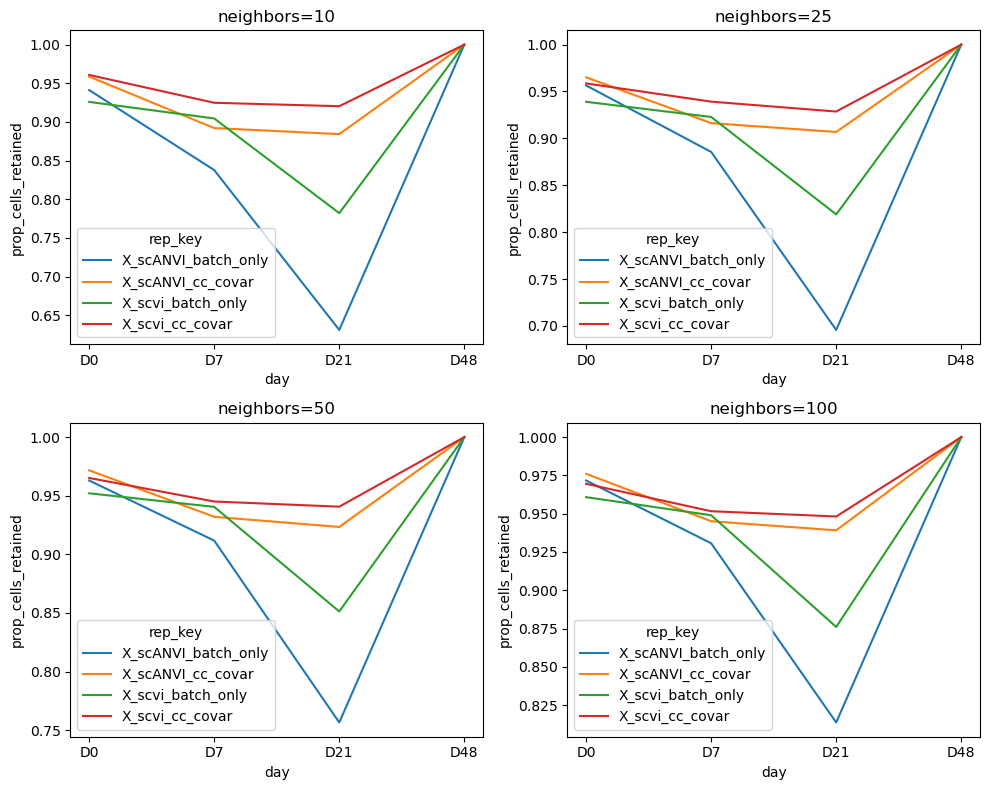

In [15]:
# retention rate by day, one panel per k, colored by representation
plt.rcdefaults()

fig, axes = plt.subplots(2, 2, figsize=(10, 8), dpi=100)
axes = axes.flatten()

for i, n in enumerate(retained_summary['k'].unique()):
    ax = axes[i]
    tmp = retained_summary[retained_summary['k'] == n]
    sns.lineplot(tmp, y='prop_cells_retained', x='day', hue='rep_key', ax=ax)
    ax.set_title(f'neighbors={n}')

plt.tight_layout()
plt.show()

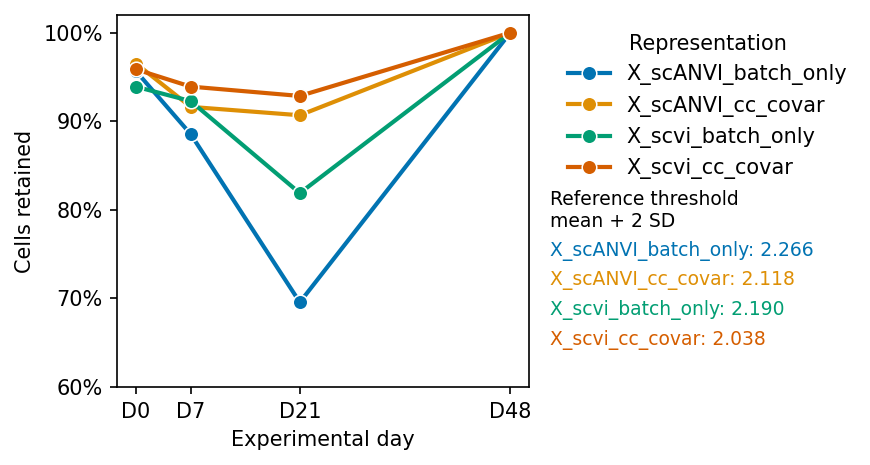

In [16]:
# publication version: single k, with reference coverage thresholds annotated
n = 25
weighted = True
day_numeric = {
    "D0": 0,
    "D7": 7,
    "D21": 21,
    "D48": 48,
}

tmp = retained_summary[
    (retained_summary["k"] == n) & (retained_summary["weighted"] == weighted)
].copy()
tmp["day_str"] = tmp["day"].astype(str)
tmp["day_num"] = tmp["day_str"].map(day_numeric)
tmp = tmp.dropna(subset=["day_num"])

cov_tmp = coverage_df[
    (coverage_df["k"] == n) & (coverage_df["weighted"] == weighted)
].copy()

rep_keys = sorted(tmp["rep_key"].unique())
palette = dict(zip(rep_keys, sns.color_palette("colorblind", n_colors=len(rep_keys))))


fig, ax = plt.subplots(figsize=(6, 3.2), dpi=150)

sns.lineplot(
    data=tmp,
    x="day_num",
    y="prop_cells_retained",
    hue="rep_key",
    marker="o",
    linewidth=2,
    markersize=7,
    palette=palette,
    ax=ax,
)

ax.set_xticks([day_numeric[d] for d in day_numeric])
ax.set_xticklabels(list(day_numeric.keys()))
ax.set_ylim(0.6, 1.02)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel("Experimental day")
ax.set_ylabel("Cells retained")
ax.legend(
    title="Representation",
    frameon=False,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

# Threshold annotation
cov_tmp = cov_tmp[cov_tmp["rep_key"].isin(rep_keys)].sort_values("rep_key")

ax.text(
    1.05, 0.42, "Reference threshold\nmean + 2 SD",
    transform=ax.transAxes, ha="left", va="bottom", fontsize=9, color="black",
)

for i, (_, row) in enumerate(cov_tmp.iterrows()):
    rep = row["rep_key"]
    ax.text(
        1.05, 0.34 - i * 0.08, f"{rep}: {row['coverage_threshold']:.3f}",
        transform=ax.transAxes, ha="left", va="bottom",
        fontsize=9, color=palette.get(rep, "black"),
    )

fig.tight_layout()
plt.show()

# Bootstrap trajectories by rep

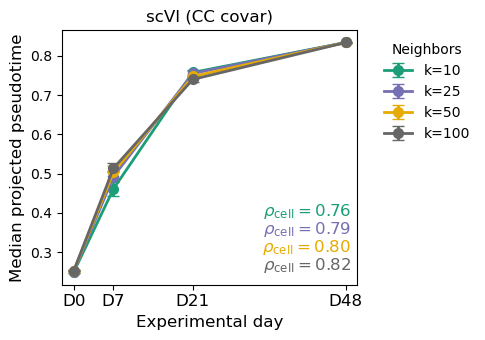

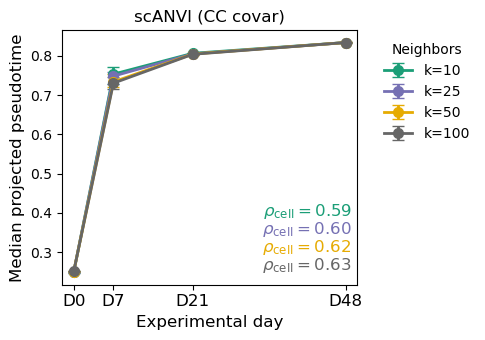

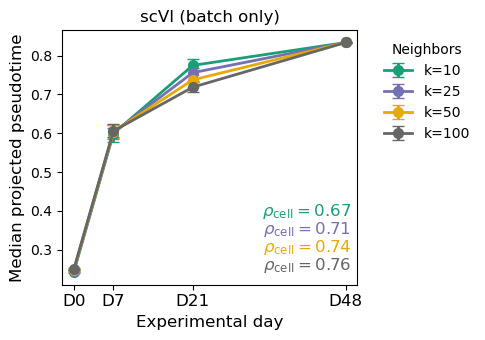

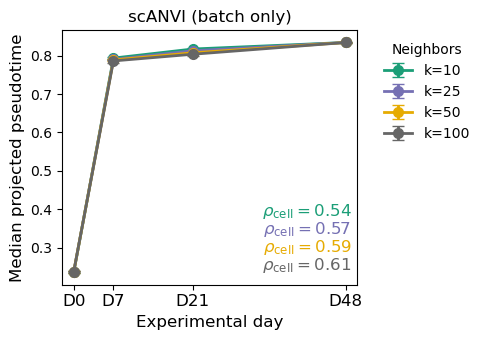

In [17]:
plt.rcdefaults()

for rep_key, title in [
    ("X_scvi_cc_covar", "scVI (CC covar)"),
    ("X_scANVI_cc_covar", "scANVI (CC covar)"),
    ("X_scvi_batch_only", "scVI (batch only)"),
    ("X_scANVI_batch_only", "scANVI (batch only)"),
]:
    plot_bootstrap_by_k_for_rep(
        boot_df=boot_df,
        rep_key=rep_key,
        days=days,
        day_numeric=day_numeric,
        stats_df=stats_df,
        cmap='Dark2',
        weighted=True,
        figsize=(5, 3.5),
        title=title,
    )

plt.show()

# Ridge plots by subcluster/day

In [18]:
### correlation check: projected pseudotime vs. day, resolved to fib-like/D48-like subclusters

# rep_key = 'X_scvi_cc_covar'
rep_key = 'X_scANVI_cc_covar'
# rep_key = 'X_scANVI_batch_only'
# rep_key = 'X_scvi_batch_only'

neighbors_key = 25

pdf = all_pdf.copy()
pdf = pdf[pdf['poor_reference_coverage'] != True]
pdf = pdf[pdf['rep_key'] == rep_key]
pdf = pdf[pdf['k'] == neighbors_key]

# group timeseries cells by subcluster label (except D0/Control, kept as-is); reference ("primary") cells are grouped by day
pdf['plot_group'] = 'none'
pdf.loc[((pdf['dataset'] == 'time-series') & (pdf['day'].isin(['D0', 'Control']))), 'plot_group'] = pdf['day']
pdf.loc[((pdf['dataset'] == 'time-series') & (~pdf['day'].isin(['D0', 'Control']))), 'plot_group'] = pdf['cluster_label']
pdf.loc[pdf['dataset'] == 'primary', 'plot_group'] = pdf['day']

clusters_to_keep = [
    'D0',
    'D7_1', # fib-like
    'D7_2', # d48-like
    'D21_2', # fib-like
    'D21_1', # d48-like
    'D48',
]

day_numeric1 = {
    "D0": 0,
    "D7_1": 5,
    "D7_2": 7,
    "D21_2": 18,
    "D21_1": 21,
    "D48": 48,
}

ts_df = pdf[pdf["plot_group"].isin(clusters_to_keep)].copy()
ts_df["day_num"] = ts_df["plot_group"].astype(str).map(day_numeric1)

rho_pt, p_pt = spearmanr(ts_df["day_num"], ts_df["projected_pseudotime"])
print(f"Projected pseudotime vs day: rho={rho_pt:.3f}, p={p_pt:.3e}")

Projected pseudotime vs day: rho=0.597, p=0.000e+00


(21053, 14)


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes he

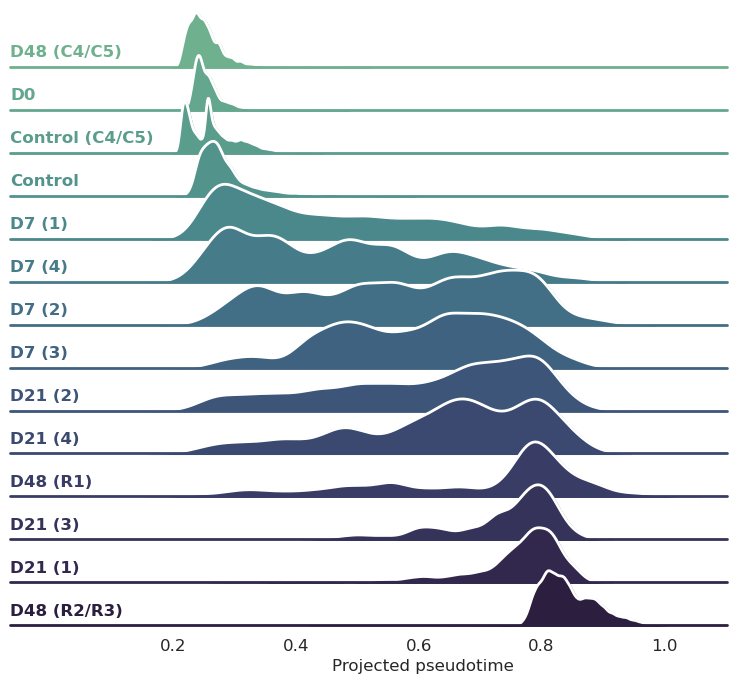

In [19]:
# ridge plot: pseudotime density per subcluster/timepoint group
rep_key = 'X_scvi_cc_covar'
neighbors_key = 25

pdf = all_pdf.copy()
pdf = pdf[pdf['poor_reference_coverage'] != True]
pdf = pdf[pdf['rep_key'] == rep_key]
pdf = pdf[pdf['k'] == neighbors_key]

pdf['plot_group'] = 'none'
pdf.loc[((pdf['dataset'] == 'time-series') & (pdf['day'].isin(['D0', 'Control']))), 'plot_group'] = pdf['day']
pdf.loc[((pdf['dataset'] == 'time-series') & (~pdf['day'].isin(['D0', 'Control']))), 'plot_group'] = pdf['cluster_label']
pdf.loc[pdf['dataset'] == 'primary', 'plot_group'] = pdf['day']

print(pdf.shape)

clusters_to_keep = [
    'control',
    'D48', 'D48_R1',
    'spike-ins',
    'Control',
    'D0',
    'D7_1',
    'D7_2',
    'D7_3',
    'D7_4',
    'D21_1',
    'D21_2',
    'D21_3',
    'D21_4',
]

group_label_map = {
    'control': 'Control (C4/C5)',
    'D48': 'D48 (R2/R3)',
    'D48_R1' : 'D48 (R1)',
    'spike-ins': 'D48 (C4/C5)',
    'Control': 'Control',
    'D0' : 'D0',
    'D7_1': 'D7 (1)',
    'D7_2': 'D7 (2)',
    'D7_3': 'D7 (3)',
    'D7_4': 'D7 (4)',
    'D21_1': 'D21 (1)',
    'D21_2': 'D21 (2)',
    'D21_3': 'D21 (3)',
    'D21_4': 'D21 (4)',
}

pdf = pdf[pdf['plot_group'].isin(clusters_to_keep)].copy()
pdf = pdf.dropna(subset=["plot_group"])
pdf['dpt_rank'] = pdf['projected_pseudotime'].rank(ascending=True, method='average').astype(int)

x_col = 'projected_pseudotime'
row_col = 'plot_group'
pdf = pdf.dropna(subset=[x_col, row_col]).copy()

# order ridges by median pseudotime, low to high
row_order = (
    pdf.groupby('plot_group', observed=True)[x_col]
    .median()
    .sort_values()
    .index
)

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
pal = sns.cubehelix_palette(
    len(row_order),
    start=.5,
    rot=-0.75,
    light=0.6
)

g = sns.FacetGrid(
    pdf,
    row=row_col,
    hue=row_col,
    aspect=15,
    height=0.5,
    row_order=row_order,
    hue_order=row_order,
    palette=pal,
    sharex=True,
    sharey=False
)

g.map(
    sns.kdeplot,
    x_col,
    bw_adjust=0.5,
    clip_on=False,
    fill=True,
    alpha=1,
    linewidth=1.5
)

g.map(
    sns.kdeplot,
    x_col,
    clip_on=False,
    color='w',
    lw=2,
    bw_adjust=0.5,
)


label_x = -0.18   # x-position of the group label text
line_xmin = -0.18 # where the ridge baseline starts (more negative extends it further left)

def extended_baseline(x, color, label):
    ax = plt.gca()
    ax.axhline(
        y=0, xmin=line_xmin, xmax=1,
        linewidth=2, linestyle="-", color=color, clip_on=False,
    )

g.map(extended_baseline, x_col)

# label each ridge
def label(x, color, label):
    ax = plt.gca()
    pretty_label = group_label_map.get(label, label)
    ax.text(
        label_x, 0.25, pretty_label,
        fontweight="bold", color=color, ha="left", va="center", transform=ax.transAxes
    )

g.map(label, x_col)


g.figure.subplots_adjust(hspace=-0.25, left=0.15) # overlap ridges
g.set_titles("")
g.set(yticks=[], ylabel="")
g.set_xlabels("Projected pseudotime", fontsize='medium')
g.despine(bottom=True, left=True)
plt.gca().tick_params(axis='x', labelsize='medium')

plt.show()

(21053, 14)


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes he

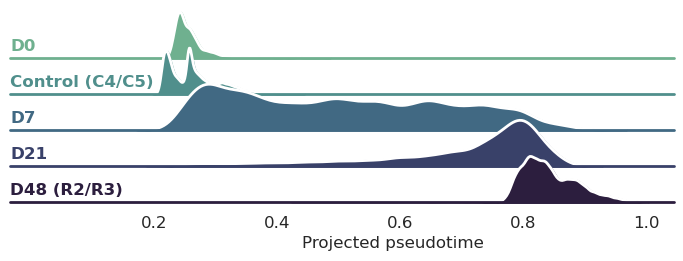

In [20]:
# same plot, but collapsed to day only (no subcluster resolution)

rep_key = 'X_scvi_cc_covar'
# rep_key = 'X_scANVI_cc_covar'
# rep_key = 'X_scANVI_batch_only'
# rep_key = 'X_scvi_batch_only'

neighbors_key = 25

pdf = all_pdf.copy()
pdf = pdf[pdf['poor_reference_coverage'] != True]
pdf = pdf[pdf['rep_key'] == rep_key]
pdf = pdf[pdf['k'] == neighbors_key]

pdf['plot_group'] = 'none'
pdf.loc[((pdf['dataset'] == 'time-series') & (pdf['day'].isin(['D0', 'Control']))), 'plot_group'] = pdf['day']
pdf.loc[((pdf['dataset'] == 'time-series') & (~pdf['day'].isin(['D0', 'Control']))), 'plot_group'] = pdf['cluster_label']
pdf.loc[pdf['dataset'] == 'primary', 'plot_group'] = pdf['day']

print(pdf.shape)

clusters_to_keep = [
    'control',
    'D48', 
    'D0',
    'D7', 
    'D21',
]

group_label_map = {
    'control': 'Control (C4/C5)',
    'D48': 'D48 (R2/R3)',
    'D48_R1' : 'D48 (R1)',
    'Control': 'Control',
    'D0' : 'D0',
    'D7': 'D7',
    'D21': 'D21',
}

pdf = pdf[pdf['day'].isin(clusters_to_keep)].copy()
pdf = pdf.dropna(subset=["day"])
pdf['dpt_rank'] = pdf['projected_pseudotime'].rank(ascending=True, method='average').astype(int)

x_col = 'projected_pseudotime'
row_col = 'day'
pdf = pdf.dropna(subset=[x_col, row_col]).copy()

row_order = (
    pdf.groupby('day', observed=True)[x_col]
    .median()
    .sort_values()
    .index
)


sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
pal = sns.cubehelix_palette(
    len(row_order),
    start=.5,
    rot=-0.75,
    light=0.6
)

g = sns.FacetGrid(
    pdf,
    row=row_col,
    hue=row_col,
    aspect=15,
    height=0.5,
    row_order=row_order,
    hue_order=row_order,
    palette=pal,
    sharex=True,
    sharey=False
)

g.map(
    sns.kdeplot,
    x_col,
    bw_adjust=0.5,
    clip_on=False,
    fill=True,
    alpha=1,
    linewidth=1.5
)

g.map(
    sns.kdeplot,
    x_col,
    clip_on=False,
    color='w',
    lw=2,
    bw_adjust=0.5,
)

label_x = -0.18   
line_xmin = -0.18 

g.map(extended_baseline, x_col)
g.map(label, x_col)

g.figure.subplots_adjust(hspace=-0.25, left=0.15)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.set_xlabels("Projected pseudotime", fontsize='medium')
g.despine(bottom=True, left=True)
plt.gca().tick_params(axis='x', labelsize='medium')

plt.show()